# Qualidade do Vinho — Classificação Multiclasse e Generalização entre Tipos

**Objetivo:** prever a categoria de qualidade de um vinho (baixa/média/alta) a partir de 11
propriedades físico-químicas — o primeiro projeto de **classificação multiclasse** do
portfólio (os três anteriores eram todos binários: crédito, Titanic, fraude). Depois, um teste
que nenhum dos outros projetos fez: treinar num tipo de vinho e testar no outro, pra ver se o
modelo generaliza entre domínios ou se são estatisticamente problemas diferentes.

**Dataset:** [Wine Quality (UCI)](https://archive.ics.uci.edu/dataset/186/wine+quality) — Cortez
et al. (2009), 1.599 vinhos tintos + 4.898 vinhos brancos portugueses, nota de qualidade de 0 a
10 dada por avaliadores especialistas (em cego, mediana de pelo menos 3 avaliações).

## 1. Importação e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

print(f"Tinto: {red.shape} | Branco: {white.shape}")
red.head()

Tinto: (1599, 12) | Branco: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Visão geral e limpeza

In [2]:
for nome, df in [('Tinto', red), ('Branco', white)]:
    print(f"{nome}: {df.isnull().sum().sum()} nulos, {df.duplicated().sum()} duplicatas")

red = red.drop_duplicates().reset_index(drop=True)
white = white.drop_duplicates().reset_index(drop=True)

print(f"\nApós remover duplicatas — Tinto: {red.shape} | Branco: {white.shape}")

Tinto: 0 nulos, 240 duplicatas
Branco: 0 nulos, 937 duplicatas

Após remover duplicatas — Tinto: (1359, 12) | Branco: (3961, 12)


## 3. Distribuição da qualidade bruta

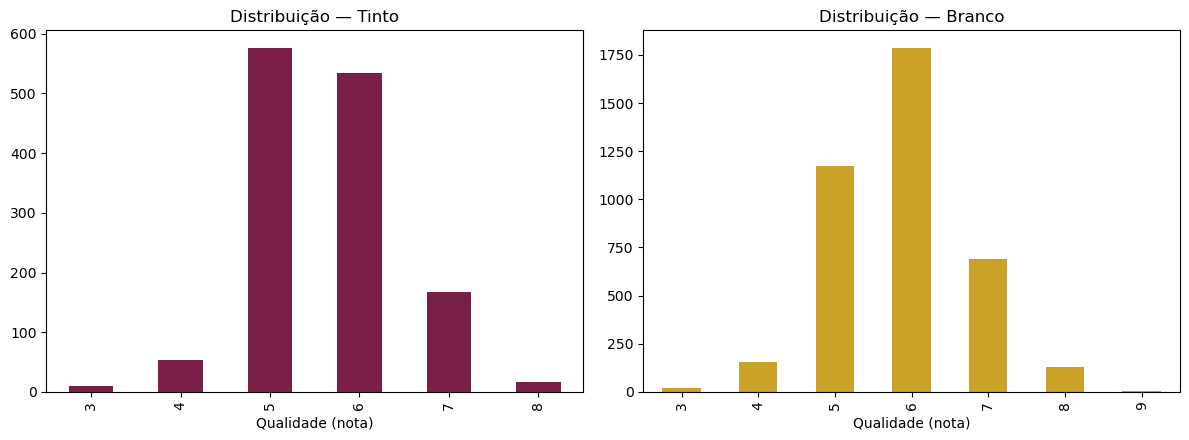

Tinto:
 quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

Branco:
 quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

red['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#7a2048')
axes[0].set_title('Distribuição — Tinto')
axes[0].set_xlabel('Qualidade (nota)')

white['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#c9a227')
axes[1].set_title('Distribuição — Branco')
axes[1].set_xlabel('Qualidade (nota)')

plt.tight_layout()
plt.show()

print("Tinto:\n", red['quality'].value_counts().sort_index())
print("\nBranco:\n", white['quality'].value_counts().sort_index())

## 4. Por que agrupar em 3 categorias

A nota bruta (3 a 9) tem classes extremas quase vazias — só 10 vinhos tintos com nota 3, e 5
brancos com nota 9. Treinar um classificador de 7 classes com tão pouco exemplo nos extremos
não é confiável. Agrupo em **baixa** (≤4), **média** (5-6) e **alta** (≥7) — categorias com
volume suficiente pra o modelo aprender de verdade, e que ainda fazem sentido de negócio
(comprador não liga pra diferença entre nota 5 e 6, liga pra "isso é bom vinho ou não").

In [4]:
def categorizar(q):
    if q <= 4:
        return 'baixa'
    elif q <= 6:
        return 'media'
    else:
        return 'alta'

red['categoria'] = red['quality'].apply(categorizar)
white['categoria'] = white['quality'].apply(categorizar)

print("Tinto:\n", red['categoria'].value_counts())
print("\nBranco:\n", white['categoria'].value_counts())

Tinto:
 categoria
media    1112
alta      184
baixa      63
Name: count, dtype: int64

Branco:
 categoria
media    2963
alta      825
baixa     173
Name: count, dtype: int64


## 5. Correlação das propriedades com a qualidade

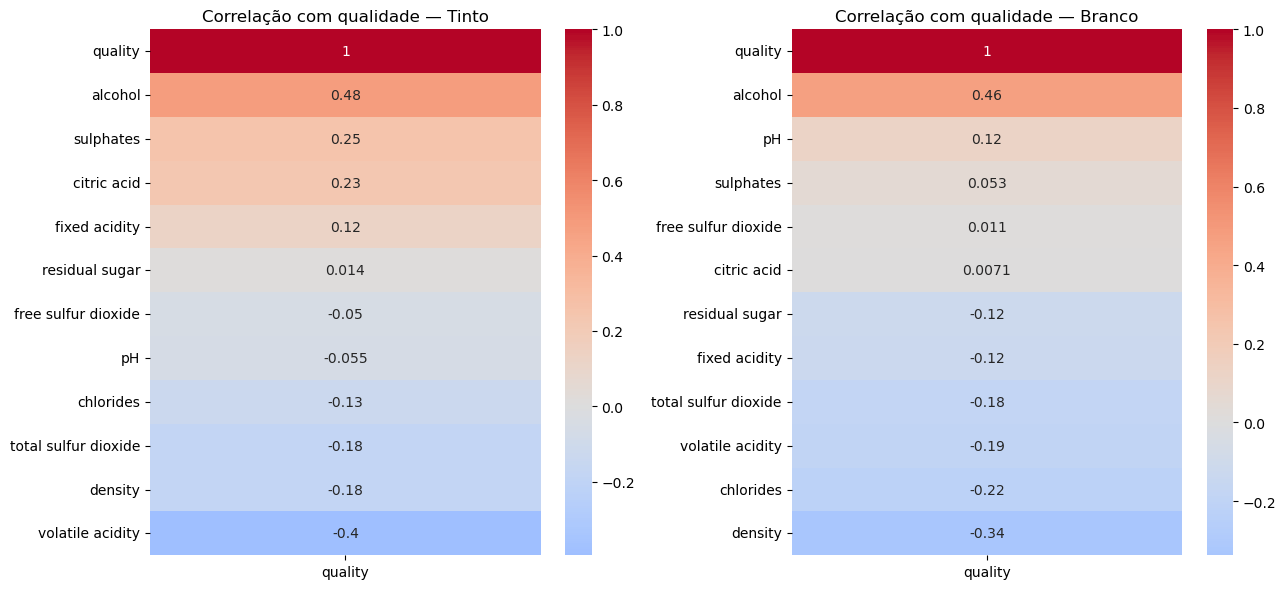

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

corr_red = red.drop(columns=['categoria']).corr()[['quality']].sort_values('quality', ascending=False)
sns.heatmap(corr_red, annot=True, cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlação com qualidade — Tinto')

corr_white = white.drop(columns=['categoria']).corr()[['quality']].sort_values('quality', ascending=False)
sns.heatmap(corr_white, annot=True, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlação com qualidade — Branco')

plt.tight_layout()
plt.show()

## 6. Preparação dos dados

Modelo principal treinado no **vinho tinto** (o dataset "de origem", menor). O branco fica
reservado pro teste de generalização mais adiante — por isso não entra no treino agora.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = [c for c in red.columns if c not in ['quality', 'categoria']]

X = red[features]
y = red['categoria']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"\nDistribuição no treino:\n{y_train.value_counts(normalize=True).round(3)}")

Treino: (1087, 11) | Teste: (272, 11)

Distribuição no treino:
categoria
media    0.819
alta     0.135
baixa    0.046
Name: proportion, dtype: float64


## 7. Três modelos de classificação multiclasse

Regressão Logística Multinomial (a extensão da Regressão Logística Binária que já usei nos
outros projetos, agora pra 3 classes), Random Forest e XGBoost multiclasse.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

modelo_lr = LogisticRegression(max_iter=2000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)
pred_lr = modelo_lr.predict(X_test_scaled)

modelo_rf = RandomForestClassifier(n_estimators=300, random_state=42)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

modelo_xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
y_train_enc = y_train.map({'baixa': 0, 'media': 1, 'alta': 2})
y_test_enc = y_test.map({'baixa': 0, 'media': 1, 'alta': 2})
modelo_xgb.fit(X_train, y_train_enc)
pred_xgb_enc = modelo_xgb.predict(X_test)
pred_xgb = pd.Series(pred_xgb_enc).map({0: 'baixa', 1: 'media', 2: 'alta'}).values

for nome, pred in [('Regressão Logística Multinomial', pred_lr), ('Random Forest', pred_rf), ('XGBoost', pred_xgb)]:
    print(f"{nome}: acurácia={accuracy_score(y_test, pred):.3f}, F1-macro={f1_score(y_test, pred, average='macro'):.3f}")

Regressão Logística Multinomial: acurácia=0.805, F1-macro=0.457
Random Forest: acurácia=0.820, F1-macro=0.506
XGBoost: acurácia=0.824, F1-macro=0.518


## 8. Achado honesto: acurácia engana de novo, agora em multiclasse

A base de treino é 81,9% "média", 13,5% "alta", só 4,6% "baixa". Um modelo que sempre chutasse
"média" já acertaria ~82% — próximo da acurácia dos 3 modelos (0,805 a 0,824). Por isso uso
**F1-macro** (trata as 3 classes com peso igual, não pondera pelo tamanho) — aí a diferença
aparece de verdade: 0,457 a 0,518, bem mais baixo, revelando que os modelos têm dificuldade real
nas classes minoritárias. XGBoost venceu nas duas métricas e é o modelo principal daqui pra
frente.

## 9. Matriz de confusão e relatório por classe (XGBoost)

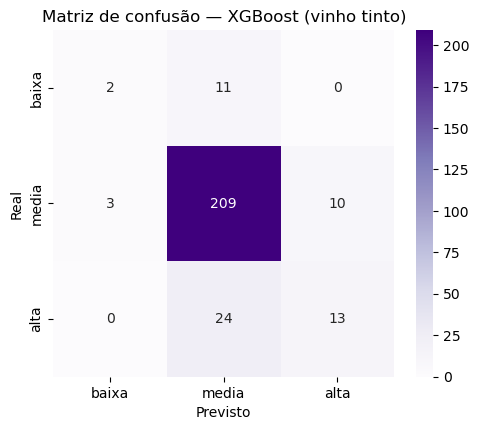

              precision    recall  f1-score   support

       baixa       0.40      0.15      0.22        13
       media       0.86      0.94      0.90       222
        alta       0.57      0.35      0.43        37

    accuracy                           0.82       272
   macro avg       0.61      0.48      0.52       272
weighted avg       0.80      0.82      0.80       272



In [8]:
ordem = ['baixa', 'media', 'alta']
cm = confusion_matrix(y_test, pred_xgb, labels=ordem)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=ordem, yticklabels=ordem)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão — XGBoost (vinho tinto)')
plt.show()

print(classification_report(y_test, pred_xgb, labels=ordem))

## 10. Teste de generalização: o modelo do tinto funciona no branco?

Nenhum dos outros projetos do portfólio testou isso: pegar um modelo treinado inteiramente num
domínio (vinho tinto) e aplicar em outro (vinho branco), sem re-treinar. Se as propriedades
físico-químicas se relacionam com qualidade do mesmo jeito nos dois tipos, o modelo deveria
generalizar razoavelmente. Se não, é sinal de que tinto e branco são, estatisticamente,
problemas diferentes — mesmo as colunas sendo idênticas.

In [9]:
X_white = white[features]
y_white = white['categoria']
y_white_enc = y_white.map({'baixa': 0, 'media': 1, 'alta': 2})

pred_white_enc = modelo_xgb.predict(X_white)
pred_white = pd.Series(pred_white_enc).map({0: 'baixa', 1: 'media', 2: 'alta'}).values

acc_cruzado = accuracy_score(y_white, pred_white)
f1_cruzado = f1_score(y_white, pred_white, average='macro')

print(f"Modelo treinado no TINTO, testado no BRANCO (n={len(white)}):")
print(f"  Acurácia: {acc_cruzado:.3f} | F1-macro: {f1_cruzado:.3f}")
print(f"\nPra comparação, dentro do próprio domínio (tinto -> tinto):")
print(f"  Acurácia: {accuracy_score(y_test, pred_xgb):.3f} | F1-macro: {f1_score(y_test, pred_xgb, average='macro'):.3f}")

Modelo treinado no TINTO, testado no BRANCO (n=3961):
  Acurácia: 0.739 | F1-macro: 0.334

Pra comparação, dentro do próprio domínio (tinto -> tinto):
  Acurácia: 0.824 | F1-macro: 0.518


## 11. Teste inverso: treinar no branco, testar no tinto

Pra não tirar conclusão de uma direção só — repito o teste treinando agora no vinho branco
(dataset maior) e testando no tinto.

In [10]:
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(
    white[features], white['categoria'], test_size=0.2, stratify=white['categoria'], random_state=42
)
y_white_train_enc = y_white_train.map({'baixa': 0, 'media': 1, 'alta': 2})
y_white_test_enc = y_white_test.map({'baixa': 0, 'media': 1, 'alta': 2})

modelo_xgb_white = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
modelo_xgb_white.fit(X_white_train, y_white_train_enc)

# dentro do proprio dominio (branco -> branco)
pred_white_test_enc = modelo_xgb_white.predict(X_white_test)
pred_white_test = pd.Series(pred_white_test_enc).map({0: 'baixa', 1: 'media', 2: 'alta'}).values
acc_branco_branco = accuracy_score(y_white_test, pred_white_test)
f1_branco_branco = f1_score(y_white_test, pred_white_test, average='macro')

# cruzado (branco -> tinto)
pred_red_enc = modelo_xgb_white.predict(red[features])
pred_red = pd.Series(pred_red_enc).map({0: 'baixa', 1: 'media', 2: 'alta'}).values
acc_branco_tinto = accuracy_score(red['categoria'], pred_red)
f1_branco_tinto = f1_score(red['categoria'], pred_red, average='macro')

print(f"Branco -> Branco (mesmo domínio): acurácia={acc_branco_branco:.3f} | F1-macro={f1_branco_branco:.3f}")
print(f"Branco -> Tinto (cruzado):        acurácia={acc_branco_tinto:.3f} | F1-macro={f1_branco_tinto:.3f}")

Branco -> Branco (mesmo domínio): acurácia=0.776 | F1-macro=0.497
Branco -> Tinto (cruzado):        acurácia=0.536 | F1-macro=0.306


## 12. Resumo dos 4 cenários

In [11]:
resumo = pd.DataFrame({
    'Cenário': ['Tinto → Tinto (mesmo domínio)', 'Tinto → Branco (cruzado)',
                'Branco → Branco (mesmo domínio)', 'Branco → Tinto (cruzado)'],
    'Acurácia': [accuracy_score(y_test, pred_xgb), acc_cruzado, acc_branco_branco, acc_branco_tinto],
    'F1-macro': [f1_score(y_test, pred_xgb, average='macro'), f1_cruzado, f1_branco_branco, f1_branco_tinto],
}).round(3)
resumo

,Cenário,Acurácia,F1-macro
0,Tinto → Tinto (mesmo domínio),0.824,0.518
1,Tinto → Branco (cruzado),0.739,0.334
2,Branco → Branco (mesmo domínio),0.776,0.497
3,Branco → Tinto (cruzado),0.536,0.306


## 13. Conclusões

**Resultado da classificação multiclasse:** XGBoost venceu com acurácia de 82,4% e F1-macro de
0,518 no vinho tinto. Olhando por classe, fica claro onde o modelo é bom e onde não é: `média`
tem F1 de 0,90 (classe majoritária, fácil), `alta` cai pra 0,43, e `baixa` — só 13 exemplos no
teste — despenca pra **0,22**. O modelo aprendeu bem o "meio do baralho" e mal os extremos,
exatamente o padrão esperado quando uma classe tem poucos exemplos.

**O resultado mais interessante do projeto — generalização entre tipos:**

| Cenário | Acurácia | F1-macro |
|---|---|---|
| Tinto → Tinto (mesmo domínio) | 0,824 | 0,518 |
| Tinto → Branco (cruzado) | 0,739 | **0,334** |
| Branco → Branco (mesmo domínio) | 0,776 | 0,497 |
| Branco → Tinto (cruzado) | **0,536** | 0,306 |

Nas duas direções, o F1-macro cai mais de 30% quando o modelo é aplicado no tipo de vinho que
ele não viu no treino. O caso mais extremo é branco→tinto: a acurácia despenca de 77,6% pra
53,6% — quase o nível de "chutar a classe majoritária". **Confirma a hipótese**: mesmo com as
mesmas 11 colunas físico-químicas, tinto e branco não são o mesmo problema estatístico — a
relação entre essas propriedades e a percepção de qualidade dos avaliadores muda de um tipo de
vinho pro outro (faz sentido: os padrões de "bom vinho" são diferentes entre as categorias —
acidez e açúcar residual, por exemplo, têm papéis bem diferentes num tinto e num branco).

**Por que isso importa na prática:** é a mesma lição de todos os projetos de diagnóstico do
portfólio, aplicada a um problema novo — um modelo com boa acurácia **no próprio domínio** não
tem garantia nenhuma de funcionar em dado de um domínio parecido, mas diferente. Isso é
literalmente o motivo pelo qual empresas re-treinam modelos por região, por segmento de
cliente, por categoria de produto — "parece a mesma coisa" não é o mesmo que "é a mesma
distribuição estatística".

**Próximos passos possíveis:**
- Testar um modelo combinado (tinto + branco juntos, com `tipo` como feature) e comparar contra
  os modelos separados — mede se dá pra ter "um modelo só" com uma feature extra em vez de dois.
- Balancear a classe `baixa` (SMOTE ou `class_weight`) e ver se o F1 dela melhora sem piorar as
  outras classes — mesmo raciocínio do projeto de fraude, agora em multiclasse.
- Regressão ordinal, já que qualidade tem ordem natural (baixa < média < alta) — pode capturar
  melhor a estrutura do problema do que classificação "solta".

## 14. Insights

"Esse foi o primeiro projeto multiclasse do portfólio — os R² e as acurácias de 82% pareciam
bons à primeira vista, mas o F1-macro por classe mostrou que o modelo é muito melhor no 'meio do
baralho' (qualidade média) do que nos extremos, que têm poucos exemplos. A parte que mais me
interessou foi testar se um modelo treinado em vinho tinto funciona em vinho branco: não
funciona bem — o F1 cai mais de 30% nas duas direções, e no pior caso (branco treinando, tinto
testando) a acurácia despenca quase ao nível de chutar a classe mais comum. Isso me mostrou, na
prática, por que empresas re-treinam modelo por segmento em vez de assumir que 'dado parecido'
é 'a mesma distribuição' — é uma armadilha fácil de cair achando que basta ter as mesmas
colunas."